In [ ]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
scenario_list = {"base":("SSP2",["base"]),
                 "narrow":("SSP2_narrow", ["base", "narrow"]),
                 "slow":("SSP2_slow",["base", "slow"]),
                 "close":("SSP2",["base", "close"]),
                 "narrow_slow_close":("SSP2_narrow_slow_close", ["base", "narrow","slow", "close"])}


In [ ]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dirs = {
        scenario: scenario_base_path / scenario for scenario in circular_scen
    }

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs) 
    vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # TODO fix this for real in the future
    prep_data = vhc_sector.prep_data

    target_materials = [
    "Aluminium", "Brick", "Cement", "Concrete", 
    "Copper", "Glass", "Steel", "Wood"
    ]

    prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
    prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

    vhc_sector = Sector('vehicles', prep_data)

    prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
    eol_sector = Sector(name="eol", data = prep_eol)

    factory = ModelFactory(
    [bld_sector, vhc_sector, eol_sector], complete_timeline
    ).add(GenericStocks, ["buildings", "vehicles"]
    ).add(GenericMaterials,  "vehicles"
    ).add(Maintenance, "vehicles"
    ).add(MaterialIntensities, "buildings",
    ).add(EndOfLife, "eol", input_sources={
    "outflow_by_cohort_materials": ["vehicles", "buildings"],
    "collection": "eol",
    "reuse": "eol",
    "recycling": "eol"}
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    all_output[scen_id] = {
        "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
        "reusable_materials": model.eol["reusable_materials"],
        "recyclable_materials": model.eol["recyclable_materials"]
    }
    print(f"Finished {scen_id}")

implemented 'base' for Residential Buildings
Finished base
implemented 'base' for Residential Buildings
implemented 'narrow' for Residential Buildings
implemented 'narrow' for Vehicles
Finished narrow
implemented 'base' for Residential Buildings
implemented 'slow' for Buildings
implemented 'slow' for Vehicles
implemented 'slow' for buildings eol
implemented 'slow' for vehicles eol
Finished slow
implemented 'base' for Residential Buildings
implemented 'close' for buildings eol
implemented 'close' for vehicles eol
Finished close
implemented 'base' for Residential Buildings
implemented 'narrow' for Residential Buildings
implemented 'slow' for Buildings
implemented 'slow' for Vehicles
implemented 'narrow' for Vehicles
implemented 'slow' for buildings eol
implemented 'slow' for vehicles eol
implemented 'close' for buildings eol
implemented 'close' for vehicles eol
Finished narrow_slow_close


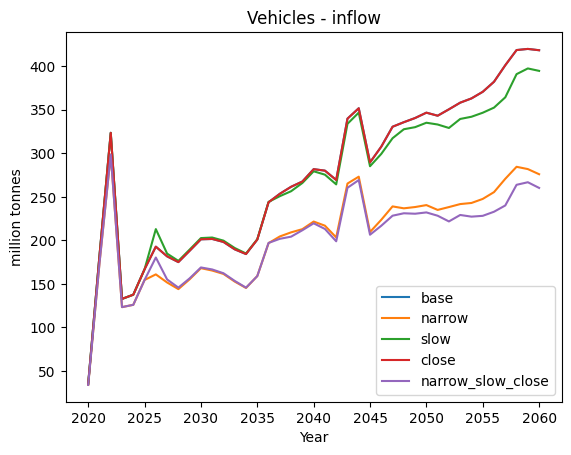

In [25]:
from matplotlib import pyplot as plt
plt.title("Vehicles - inflow")
plt.xlabel("Year")
plt.ylabel("million tonnes")
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type")/1e9, label=scen_id)
plt.legend()
plt.show()

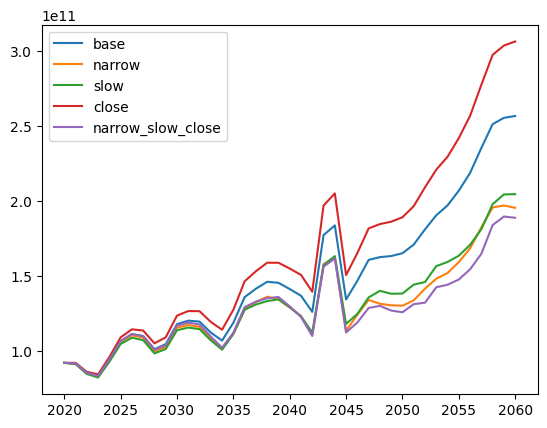

In [ ]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["recyclable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()
plt.show()

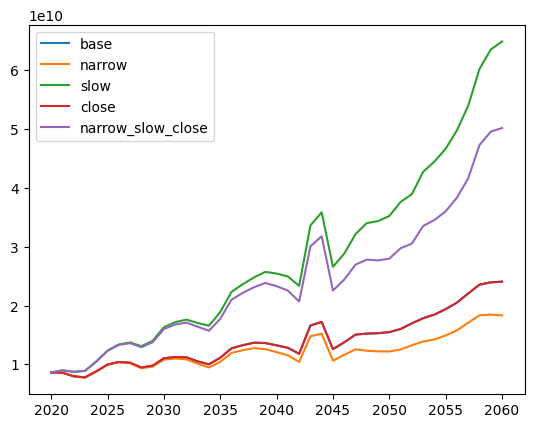

In [21]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["reusable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()